In [1]:
n_jobs= 60
#libraries
import pandas as pd
import numpy as np
import os
import sys
from glob import glob
import joblib
import warnings
from datetime import date, datetime
import copy

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from scipy.stats import pearsonr
import scipy.stats as st

from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

import pickle

from sklearn.compose import TransformedTargetRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import PowerTransformer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#path to dir
path='/scratch2/alinat/project/PD-EEG-ANON_eegOnly/MLtables180/MLout/performance_boot_ZnoLG_lvl1_lvl2_lvlFlat_tabs'

In [3]:
#lvl1
dct_lvl1_bt = {}
for file in glob(path+'/MLlvl1_*_r2_performance_bootstr.csv'):
    tab = pd.read_csv(file, index_col=0)
    dct_lvl1_bt[file.split('/')[-1].replace('MLlvl1_global_z_no_language__', '').replace('_r2_performance_bootstr.csv', '')] = tab

mods_names = dct_lvl1_bt['enet'].columns

dct_tab_modwise = {}
for mod in mods_names:
    tab = pd.DataFrame()
    for key in list(dct_lvl1_bt.keys()):
        tab[mod+'__'+key] = pd.Series(dct_lvl1_bt[key][mod])
    dct_tab_modwise[mod] = tab


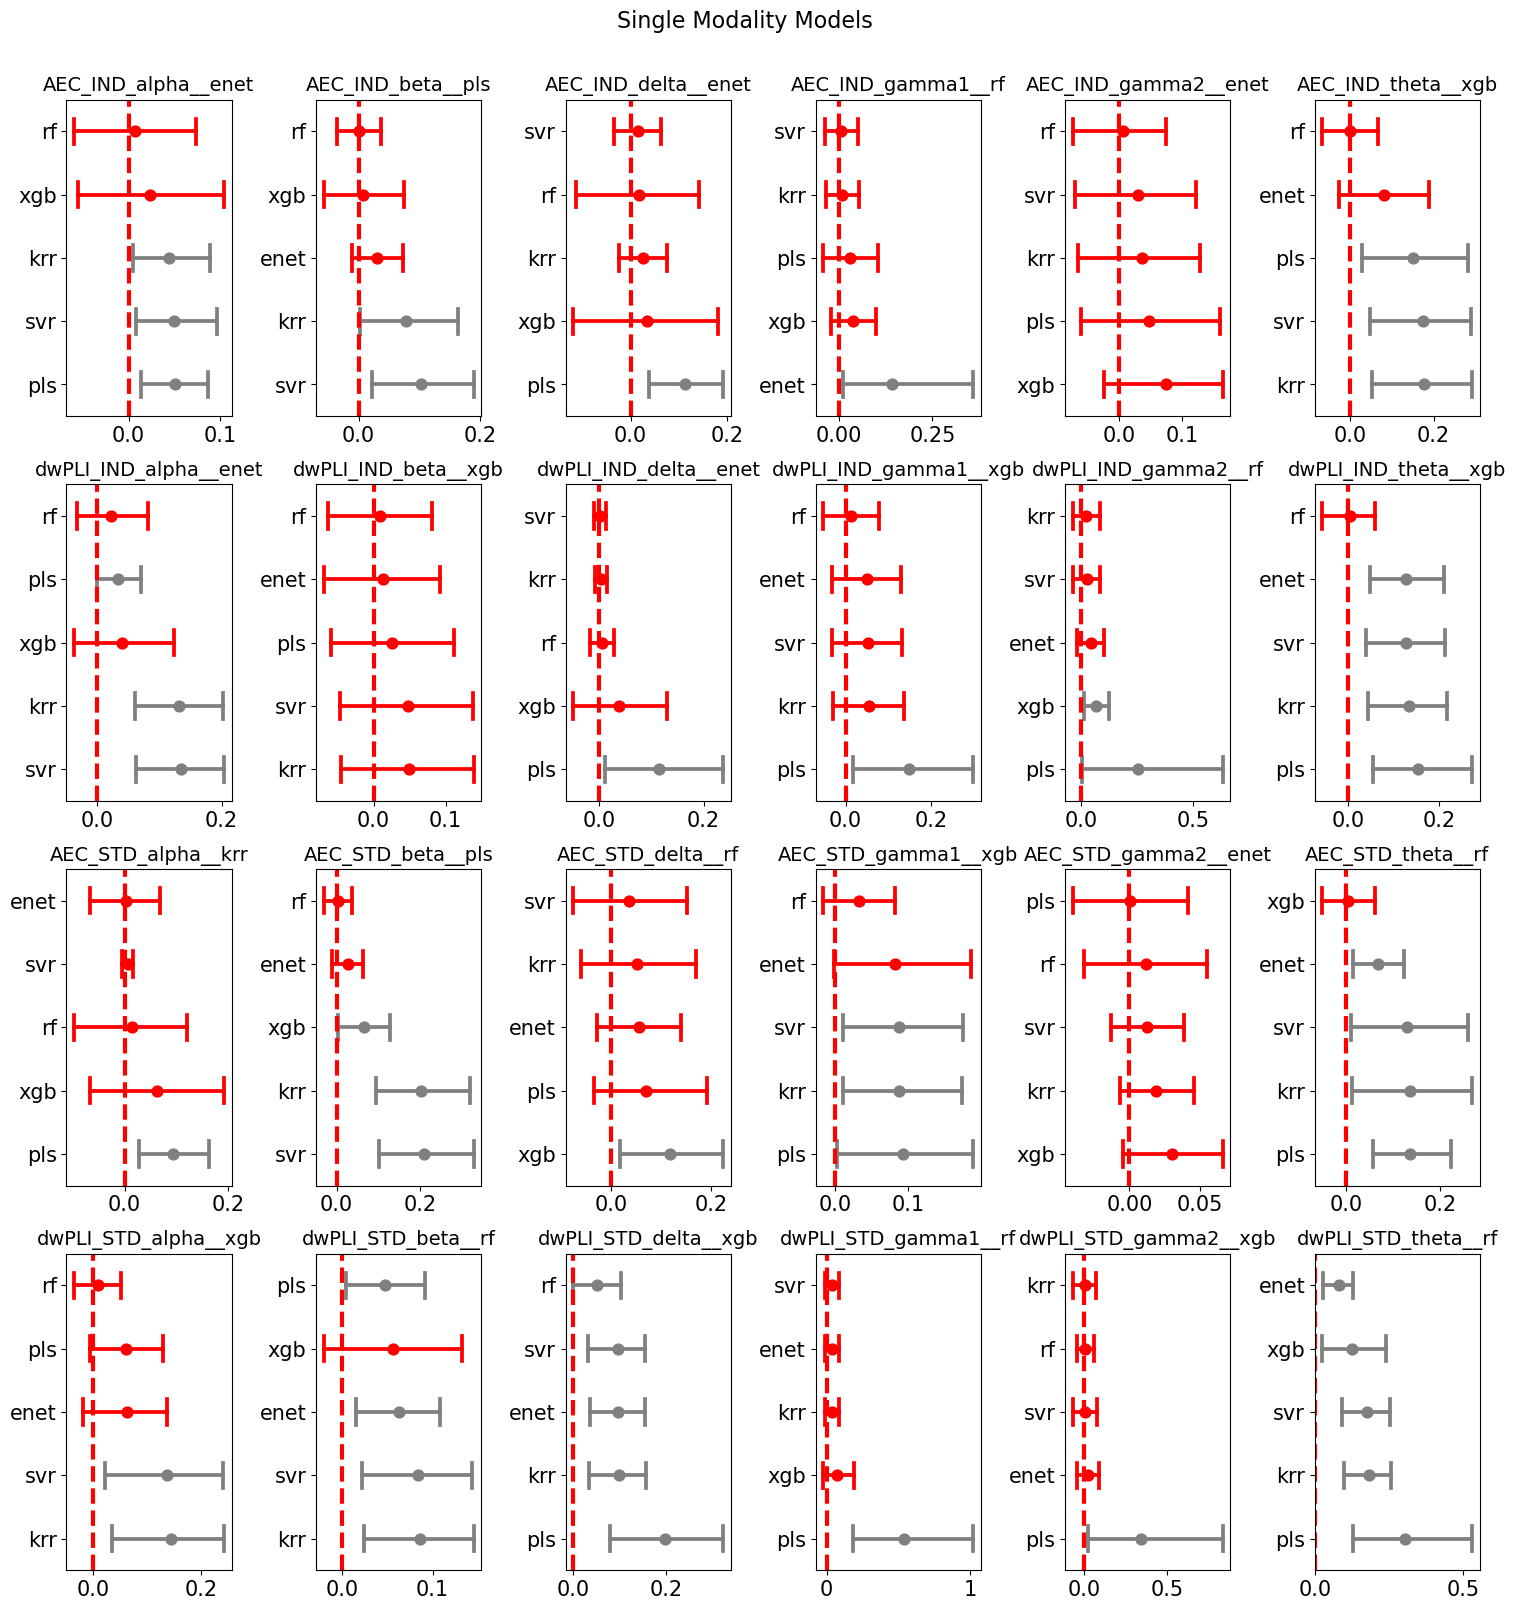

In [16]:
# #calculate bootstr difference and CI, and plot
# #best model in each modality

# Set up the grid
#n_plots = len(dct_tab_modwise)
ncols = 6
nrows = 5 #int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2.5 * ncols, 4 * nrows))
axes = axes.flatten()  # Flatten to 1D for easy indexing

# Loop through each modality and subplot
for idx, modality in enumerate([i for i in dct_tab_modwise.keys() if 'ANAT' not in i]): #dct_tab_modwise.keys()
    ax = axes[idx]

    tab = dct_tab_modwise[modality]
    best_mod_indx = tab.mean().sort_values(ascending=False).index[0]
    tab2 = tab.drop(best_mod_indx, axis=1)

    difference = pd.DataFrame()
    for col in tab2.columns:
        differ = tab[best_mod_indx] - tab2[col]
        difference[best_mod_indx + '___' + col] = differ

    data = difference.reindex(columns=difference.mean().sort_values().index)
    data.columns = [i.replace('_diagonal_', '_') for i in data.columns]
    data.columns = [i.replace('aec_ind', 'AEC_IND').replace('aec_std', 'AEC_STD').replace('dwpli_ind', 'dwPLI_IND').replace('dwpli_std', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in data.columns]
    data.columns = [i.replace('IND_aec', 'AEC_IND').replace('STD_aec', 'AEC_STD').replace('IND_dwpli', 'dwPLI_IND').replace('STD_dwpli', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in data.columns]
    targ_mod_ttl = data.columns[0].split('___')[0]
    data.columns = [i.split('___')[-1].split('__')[-1] for i in data.columns]


    #data = data.reindex(columns=[i for i in data.columns if 'STR' not in i])

    # Color palette
    my_pal = ['red' if np.percentile(data[col], 2.5) < 0 else 'gray' for col in data.columns]

    # Plot
    def my_func(vec):
        return np.percentile(vec, [2.5, 97.5])

    sns.pointplot(data=data, orient='h', errorbar=my_func, capsize=0.4, palette=my_pal, ax=ax)
    ax.axvline(0, color='r', linestyle='dashed', linewidth=3)
    ax.set_title(targ_mod_ttl, fontsize=14)
    ax.tick_params(labelsize=15)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Single Modality Models\n\n', fontsize=16)
plt.tight_layout()
plt.show()


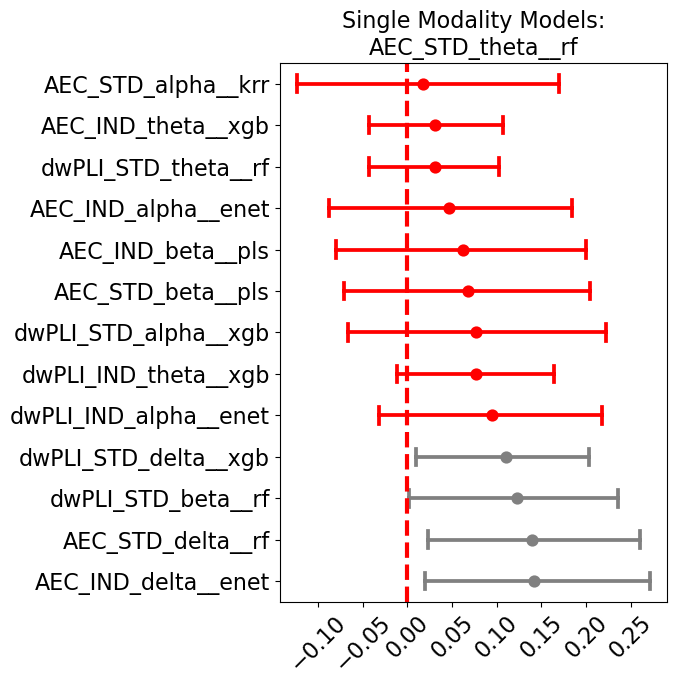

In [9]:
#compare between modality (pick the best model in modality by the mean) # for ind and std only
dct_tab_bestwise = {}
for modality in list(dct_tab_modwise.keys()):
    
    tab = dct_tab_modwise[modality]
    #best model in modality
    best_mod_indx = tab.mean().sort_values(ascending=False).index[0]
    dct_tab_bestwise[best_mod_indx] = tab[best_mod_indx]

tab = pd.DataFrame(dct_tab_bestwise)
best_mod_indx = tab.mean().sort_values(ascending=False).index[0]
tab2 = copy.deepcopy(tab)
tab2 = tab2.drop(best_mod_indx,axis=1)

difference = pd.DataFrame()
for col in tab2.columns:
    differ = tab[best_mod_indx] - tab2[col]
    difference[best_mod_indx+'___'+col] = differ 

#data to plot
data = difference.reindex(columns=difference.mean().sort_values().index)
data.columns = [i.replace('_diagonal_', '_') for i in data.columns]
data.columns = [i.replace('aec_ind', 'AEC_IND').replace('aec_std', 'AEC_STD').replace('dwpli_ind', 'dwPLI_IND').replace('dwpli_std', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in data.columns]
data.columns = [i.replace('IND_aec', 'AEC_IND').replace('STD_aec', 'AEC_STD').replace('IND_dwpli', 'dwPLI_IND').replace('STD_dwpli', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in data.columns]

targ_mod_ttl = data.columns[0].split('___')[0]
data.columns = [i.split('___')[-1] for i in data.columns] #set correct ylabel names by renaming columns
data = data.reindex(columns = [i for i in data.columns if 'IND' in i or 'STD' in i])

data = data.iloc[:,:13]

#make pallette
my_pal = []
for col in data.columns:
    ci1 = np.percentile(data[col], [2.5, 97.5])[0]
    if ci1 <0:
        my_pal += ['red']
    else:
        my_pal += ['gray']

#plotting func
fig = plt.figure(figsize=(5,7))#(figsize=(5,10))

def my_func(vec):
    ci = np.percentile(vec, [2.5, 97.5])
    return ci

sns.pointplot(data = data, orient='h',  errorbar=my_func, capsize=.4,  palette=my_pal)

plt.axvline(0, color='r', linestyle='dashed', linewidth=3)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)

plt.title('Single Modality Models:\n'+targ_mod_ttl, fontsize=16)

plt.show()

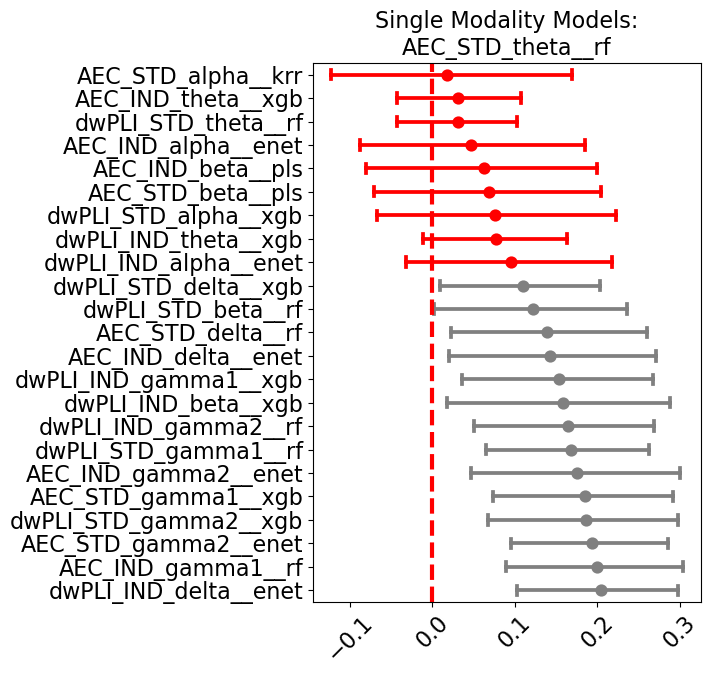

In [10]:
#compare between modality (pick the best model in modality by the mean) # for ind and std only
dct_tab_bestwise = {}
for modality in list(dct_tab_modwise.keys()):
    
    tab = dct_tab_modwise[modality]
    #best model in modality
    best_mod_indx = tab.mean().sort_values(ascending=False).index[0]
    dct_tab_bestwise[best_mod_indx] = tab[best_mod_indx]

tab = pd.DataFrame(dct_tab_bestwise)
best_mod_indx = tab.mean().sort_values(ascending=False).index[0]
tab2 = copy.deepcopy(tab)
tab2 = tab2.drop(best_mod_indx,axis=1)

difference = pd.DataFrame()
for col in tab2.columns:
    differ = tab[best_mod_indx] - tab2[col]
    difference[best_mod_indx+'___'+col] = differ 

#data to plot
data = difference.reindex(columns=difference.mean().sort_values().index)
data.columns = [i.replace('_diagonal_', '_') for i in data.columns]
data.columns = [i.replace('aec_ind', 'AEC_IND').replace('aec_std', 'AEC_STD').replace('dwpli_ind', 'dwPLI_IND').replace('dwpli_std', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in data.columns]
data.columns = [i.replace('IND_aec', 'AEC_IND').replace('STD_aec', 'AEC_STD').replace('IND_dwpli', 'dwPLI_IND').replace('STD_dwpli', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in data.columns]

targ_mod_ttl = data.columns[0].split('___')[0]
data.columns = [i.split('___')[-1] for i in data.columns] #set correct ylabel names by renaming columns
data = data.reindex(columns = [i for i in data.columns if 'IND' in i or 'STD' in i])

data = data#.iloc[:,:13]

#make pallette
my_pal = []
for col in data.columns:
    ci1 = np.percentile(data[col], [2.5, 97.5])[0]
    if ci1 <0:
        my_pal += ['red']
    else:
        my_pal += ['gray']

#plotting func
fig = plt.figure(figsize=(5,7))#(figsize=(5,10))

def my_func(vec):
    ci = np.percentile(vec, [2.5, 97.5])
    return ci

sns.pointplot(data = data, orient='h',  errorbar=my_func, capsize=.4,  palette=my_pal)

plt.axvline(0, color='r', linestyle='dashed', linewidth=3)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)

plt.title('Single Modality Models:\n'+targ_mod_ttl, fontsize=16)

plt.show()